In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# set WD to /gpfs/commons/groups/knowles_lab/data/sc/rockefeller_2022 
os.chdir('/gpfs/commons/groups/knowles_lab/data/sc/rockefeller_2022')

# make some summary plots distribution of cells by sex by type and by main cluster name
sns.set_theme(style='whitegrid')
sns.set_context('notebook')
sns.set_palette('colorblind')

# read cells file Cell_annotation.csv
cells = pd.read_csv('Cell_annotation.csv')

In [2]:
cells.head()

,Cell_random_hexamer,Cell_shortDT,UMI_count,Gene_count,PCR_sample_name,Ligation_barcode,RT_barcode_random_hexamer,RT_barcode_shortDT,umap_1,umap_2,Louvain_cluster,Type,Sex,Replicate_ID,Main_cluster_name,Subcluster_id,Subcluster_umap_1,Subcluster_umap_2,Sub_cluster_num
0,EasySci_001.AACCGATTGCATGCAATATG,EasySci_001.AACCGATTGCAATCGAACTC,558,379,EasySci_001,AACCGATTGC,ATGCAATATG,AATCGAACTC,0.345946,4.792399,7,5xFAD,male,1,Cerebellum granule neurons,Cerebellum granule neurons_1,1.337663,-3.196105,1.0
1,EasySci_001.AACCGATTGCTTAGCAATAA,EasySci_001.AACCGATTGCACTCCGCCAA,3180,1371,EasySci_001,AACCGATTGC,TTAGCAATAA,ACTCCGCCAA,7.559918,-3.935702,6,3mo,male,2,Interbrain and midbrain neurons 2,Interbrain and midbrain neurons 2_1,-0.875215,-2.433680,1.0
2,EasySci_001.AACCGATTGCAGCTAAGGTA,EasySci_001.AACCGATTGCAGCGATCCGC,3132,1657,EasySci_001,AACCGATTGC,AGCTAAGGTA,AGCGATCCGC,8.763198,-3.253150,31,6mo,male,1,Interbrain and midbrain neurons 2,Interbrain and midbrain neurons 2_2,2.808076,3.226601,2.0
3,EasySci_001.AACCGATTGCTCTCCTATAA,EasySci_001.AACCGATTGCCATCCAGCCA,10028,3436,EasySci_001,AACCGATTGC,TCTCCTATAA,CATCCAGCCA,7.853685,-3.673076,30,APOE4/TREM2,male,2,Interbrain and midbrain neurons 2,Interbrain and midbrain neurons 2_3,1.555948,0.093578,3.0
4,EasySci_001.AACCGATTGCCGCCTCGAAC,EasySci_001.AACCGATTGCCCAGGCTCTT,953,610,EasySci_001,AACCGATTGC,CGCCTCGAAC,CCAGGCTCTT,-7.504099,0.636785,47,6mo,male,1,Oligodendrocyte progenitor cells,Oligodendrocyte progenitor cells_1,3.020408,-0.754258,1.0


In [3]:
# breakdown of number of cells in each sample type get breakdown by type, sex, and main cluster_name count via cell_random_hexamer column
summary = pd.DataFrame(cells.groupby(['Sex', 'Type', 'Main_cluster_name']).Cell_random_hexamer.count()).reset_index()
# rename last column to num_cells 
summary.rename(columns={'Cell_random_hexamer': 'num_cells'}, inplace=True)
summary.head()

,Sex,Type,Main_cluster_name,num_cells
0,female,21mo,Astrocytes,5680
1,female,21mo,Bergmann glia,800
2,female,21mo,Cerebellum granule neurons,42702
3,female,21mo,Cerebellum interneurons,2791
4,female,21mo,Choroid plexus epithelial cells,326


In [4]:
summary = summary.sort_values(by='num_cells', ascending=False)

<Axes: xlabel='num_cells', ylabel='Main_cluster_name'>

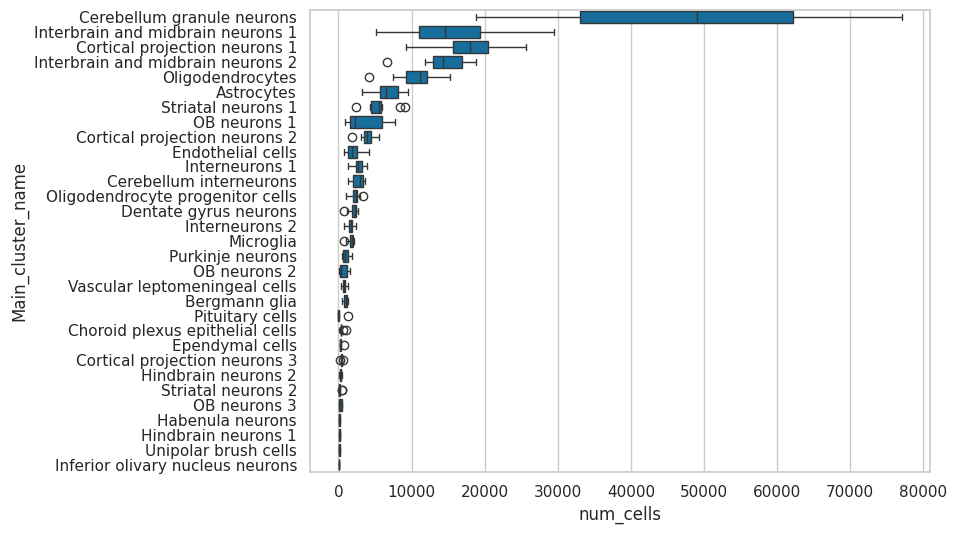

In [5]:
# use boxplot to show number of cells across different groups
plt.figure(figsize=(8, 6))
sns.boxplot(data=summary, y="Main_cluster_name", x="num_cells")

<Axes: xlabel='num_cells', ylabel='Sex'>

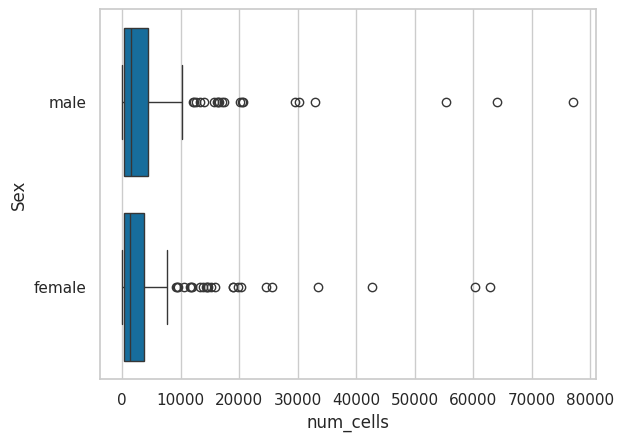

In [6]:
sns.boxplot(data=summary, y="Sex", x="num_cells")

<Axes: xlabel='num_cells', ylabel='Type'>

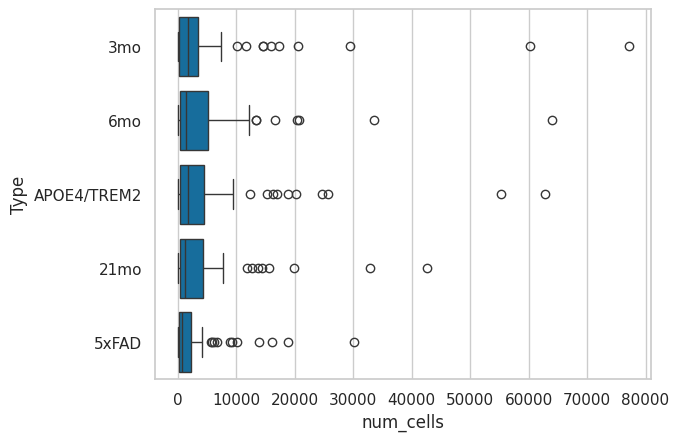

In [7]:
sns.boxplot(data=summary, y="Type", x="num_cells")

<Axes: xlabel='num_cells', ylabel='Main_cluster_name'>

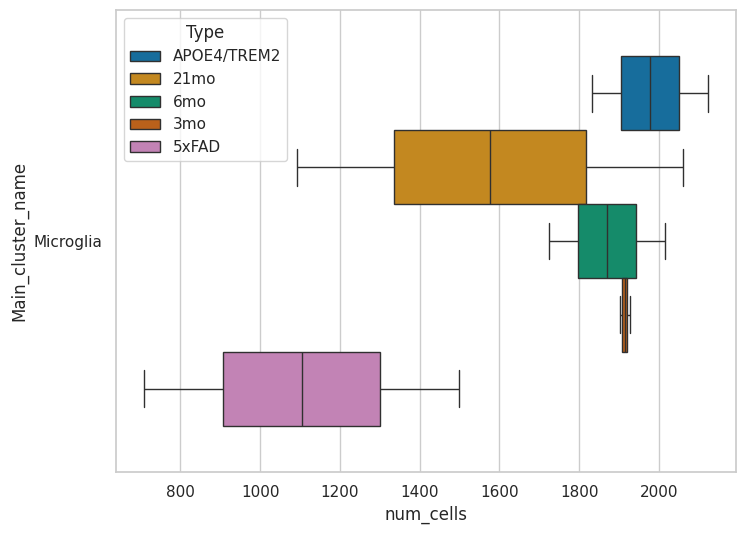

In [8]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=summary[summary["Main_cluster_name"] == "Microglia"], y="Main_cluster_name", x="num_cells", hue = "Type")